# CSE-CIC-IDS2018 Exploratory Data Analysis

This notebook explores the CSE-CIC-IDS2018 network intrusion detection dataset.

## Objectives:
1. Load data using Pandas
2. Understand data quality and missing values
3. Analyze label distribution and class imbalance
4. Explore feature correlations
5. Identify temporal patterns in attacks
6. Characterize different attack types

In [1]:
# Import libraries
import os
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

## 1. Load Data

In [7]:
# Load all CSV files, stripping duplicate embedded header rows, cast to schema types
from pathlib import Path
import sys

# Find repo root robustly (works regardless of current working directory)
cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "src").exists() and (p / "data").exists()),
    cwd,
)
sys.path.insert(0, str(project_root))

from src.schemas.cse_cic_ids2018 import PANDAS_DTYPES, TIMESTAMP_FORMAT

data_path = project_root / 'data' / 'raw' / 'CSE-CIC-IDS2018'
csv_files = sorted(data_path.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  {f.name}")

if not csv_files:
    raise FileNotFoundError(f"No CSV files found under: {data_path}")

# Step 1: Read all as strings to avoid type errors on embedded header rows
frames = []
for f in csv_files:
    raw = pd.read_csv(f, header=0, dtype=str, on_bad_lines='skip')
    # Drop rows where the first column value equals the column name (embedded headers)
    first_col = raw.columns[0]
    raw = raw[raw[first_col] != first_col]
    frames.append(raw)

df = pd.concat(frames, ignore_index=True)

# Step 2: Cast numeric columns per schema (Infinity / bad values become NaN)
for col_name, dtype in PANDAS_DTYPES.items():
    if col_name not in df.columns or dtype == "object":
        continue
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce').astype(dtype)

# Step 3: Parse Timestamp
if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format=TIMESTAMP_FORMAT, errors='coerce')

print(f"\nLoaded {len(df):,} records")
print(f"Number of features: {len(df.columns)}")


Found 10 CSV files:
  02-14-2018.csv
  02-15-2018.csv
  02-16-2018.csv
  02-20-2018.csv
  02-21-2018.csv
  02-22-2018.csv
  02-23-2018.csv
  02-28-2018.csv
  03-01-2018.csv
  03-02-2018.csv

Loaded 16,232,943 records
Number of features: 84


In [8]:
print(f"Pandas DataFrame shape: {df.shape}")
df.head()

Pandas DataFrame shape: (16232943, 84)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Flow ID,Src IP,Src Port,Dst IP
0,0,0,NaT,112641719,3,0,0,0,0.0,0.0,...,0,56320859.5,139.300036,56320958,56320761,Benign,NaN,NaN,NaN,NaN
1,0,0,NaT,112641466,3,0,0,0,0.0,0.0,...,0,56320733.0,114.551299,56320814,56320652,Benign,NaN,NaN,NaN,NaN
2,0,0,NaT,112638623,3,0,0,0,0.0,0.0,...,0,56319311.5,301.934596,56319525,56319098,Benign,NaN,NaN,NaN,NaN
3,22,6,NaT,6453966,15,10,1239,2273,744.0,0.0,...,0,0.0,0.000000,0,0,Benign,NaN,NaN,NaN,NaN
4,22,6,NaT,8804066,14,11,1143,2209,744.0,0.0,...,0,0.0,0.000000,0,0,Benign,NaN,NaN,NaN,NaN


## 2. Data Quality Analysis

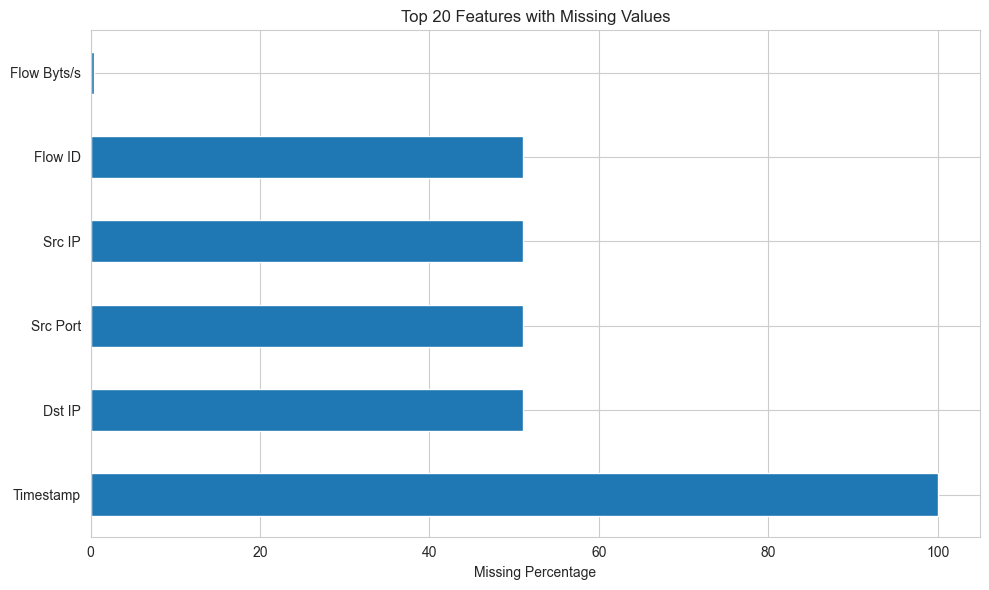

In [9]:
# Check missing values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    plt.figure(figsize=(10, 6))
    missing_pct.head(20).plot(kind='barh')
    plt.xlabel('Missing Percentage')
    plt.title('Top 20 Features with Missing Values')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

## 3. Label Distribution

In [10]:
# Label distribution
label_counts = df['Label'].value_counts()
print("\nAttack Distribution:")
print(label_counts)
print(f"\nClass imbalance ratio: {label_counts.max() / label_counts.min():.2f}")


Attack Distribution:
Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64

Class imbalance ratio: 154996.64


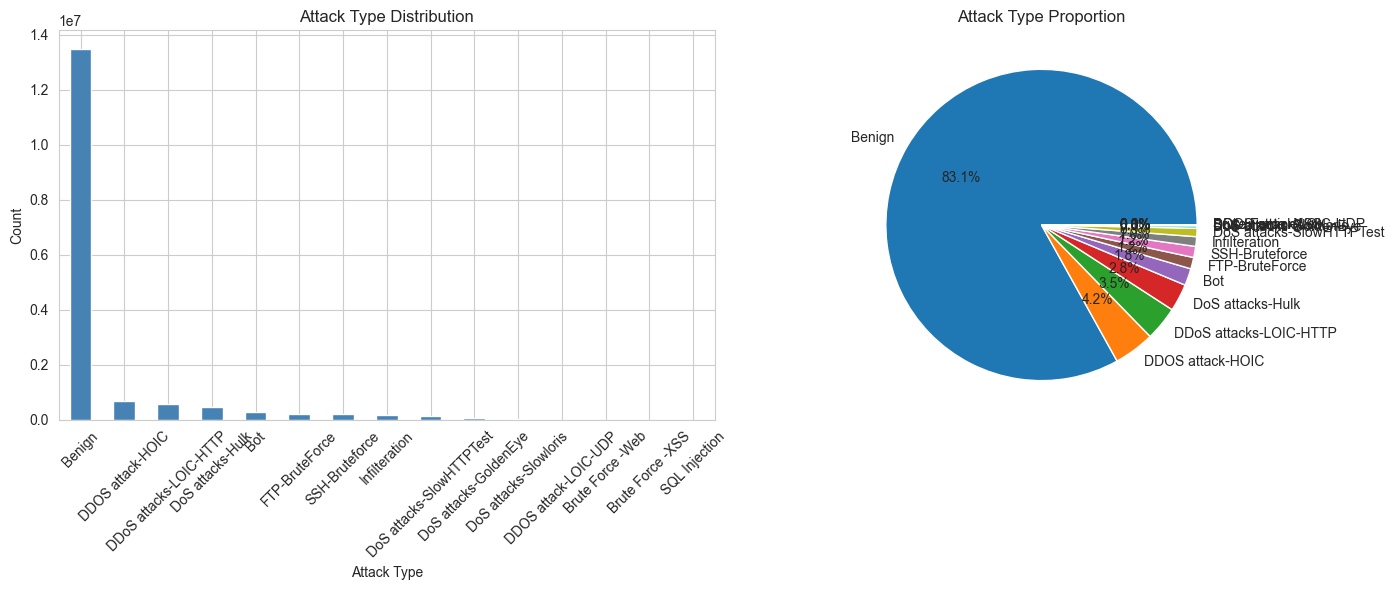

In [11]:
# Visualize label distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
label_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Attack Type Distribution')
ax1.set_xlabel('Attack Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart
label_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%')
ax2.set_ylabel('')
ax2.set_title('Attack Type Proportion')

plt.tight_layout()
plt.show()

## 4. Feature Correlation Analysis

Found 78 numeric features

First 20 numeric columns:
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max']

Using 8 features for correlation analysis


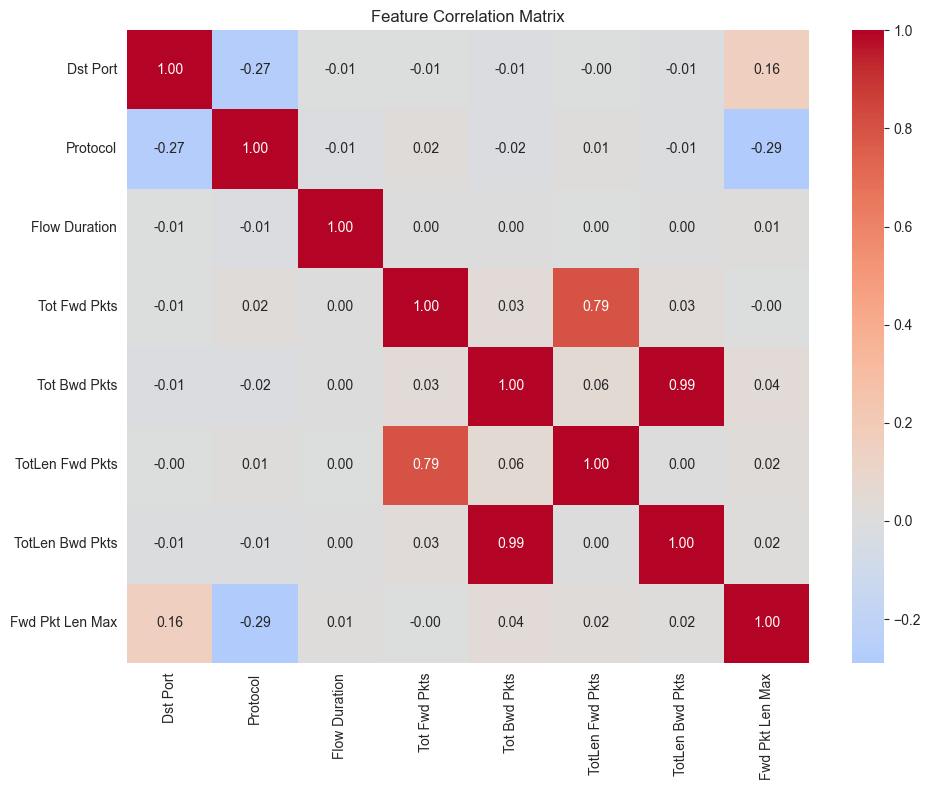

In [12]:
# Select numeric features for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove label column if present
label_cols = ['label', 'Label', 'Attack']  # Adjust based on actual label column name
numeric_cols = [c for c in numeric_cols if c not in label_cols]

print(f"Found {len(numeric_cols)} numeric features")
print("\nFirst 20 numeric columns:")
print(numeric_cols[:20])

# Select top features by name similarity (adjust based on actual column names)
# Use columns that actually exist in the dataset
if len(numeric_cols) >= 8:
    # Take first 8 numeric features for correlation
    key_features = numeric_cols[:8]
else:
    key_features = numeric_cols

print(f"\nUsing {len(key_features)} features for correlation analysis")

corr_matrix = df[key_features].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Attack Characteristics

Visualizing features: ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts']


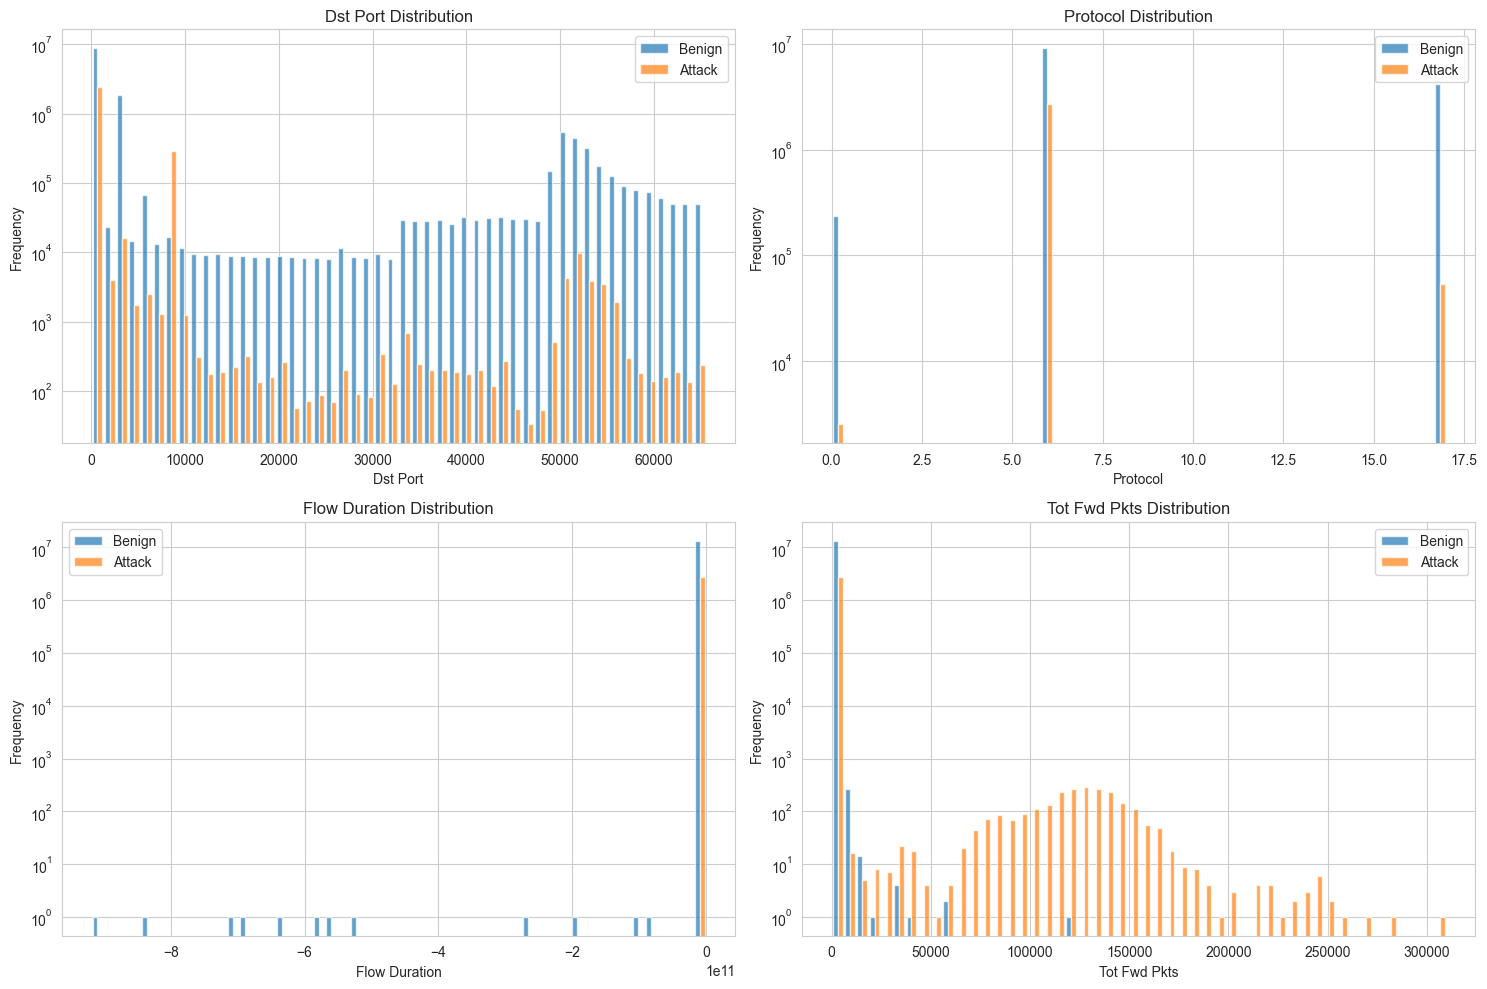

In [13]:
# Compare benign vs attack flows
df['is_attack'] = (df['Label'] != 'Benign').astype(int)

# Use actual numeric columns from the dataset (first 4 for visualization)
numeric_features = [c for c in numeric_cols[:4]]

print(f"Visualizing features: {numeric_features}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    if feature in df.columns:
        benign = df[df['is_attack'] == 0][feature].dropna()
        attack = df[df['is_attack'] == 1][feature].dropna()
        
        axes[idx].hist([benign, attack], label=['Benign', 'Attack'], bins=50, alpha=0.7)
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{feature} Distribution')
        axes[idx].legend()
        try:
            axes[idx].set_yscale('log')
        except:
            pass  # Skip log scale if it causes issues

plt.tight_layout()
plt.show()

## 6. Next Steps

Based on this EDA:
1. Class imbalance requires special handling (SMOTE, class weights)
2. Some features show strong correlation - consider dimensionality reduction
3. Attack types have distinct characteristics - feature engineering opportunities
4. Temporal patterns suggest time-based features are important

Proceed to:
- `02_feature_engineering.ipynb` for advanced feature creation
- `03_model_training.ipynb` for model development